In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use("seaborn-v0_8")
sns.set_theme()

# Load dataset
df = pd.read_csv("../data/processed/climate_multicity.csv")

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,PS,Date,City
0,24.14,27.83,21.54,81.89,0.00,2.96,100.70,2010-01-01,Chennai
1,23.77,26.94,21.18,81.10,0.01,3.25,100.89,2010-01-02,Chennai
2,23.32,26.58,20.84,79.15,0.01,3.03,100.88,2010-01-03,Chennai
3,22.86,26.46,20.49,77.30,0.00,2.10,100.71,2010-01-04,Chennai
4,22.83,26.80,19.15,79.50,0.00,2.01,100.55,2010-01-05,Chennai


In [4]:
df.shape

(27395, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27395 entries, 0 to 27394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   T2M          27395 non-null  float64       
 1   T2M_MAX      27395 non-null  float64       
 2   T2M_MIN      27395 non-null  float64       
 3   RH2M         27395 non-null  float64       
 4   PRECTOTCORR  27395 non-null  float64       
 5   WS2M         27395 non-null  float64       
 6   PS           27395 non-null  float64       
 7   Date         27395 non-null  datetime64[ns]
 8   City         27395 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 1.9+ MB


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27395 entries, 0 to 27394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   T2M          27395 non-null  float64       
 1   T2M_MAX      27395 non-null  float64       
 2   T2M_MIN      27395 non-null  float64       
 3   RH2M         27395 non-null  float64       
 4   PRECTOTCORR  27395 non-null  float64       
 5   WS2M         27395 non-null  float64       
 6   PS           27395 non-null  float64       
 7   Date         27395 non-null  datetime64[ns]
 8   City         27395 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 1.9+ MB


In [7]:
df.replace(-999, np.nan, inplace=True)

df.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
RH2M           0
PRECTOTCORR    0
WS2M           0
PS             0
Date           0
City           0
dtype: int64

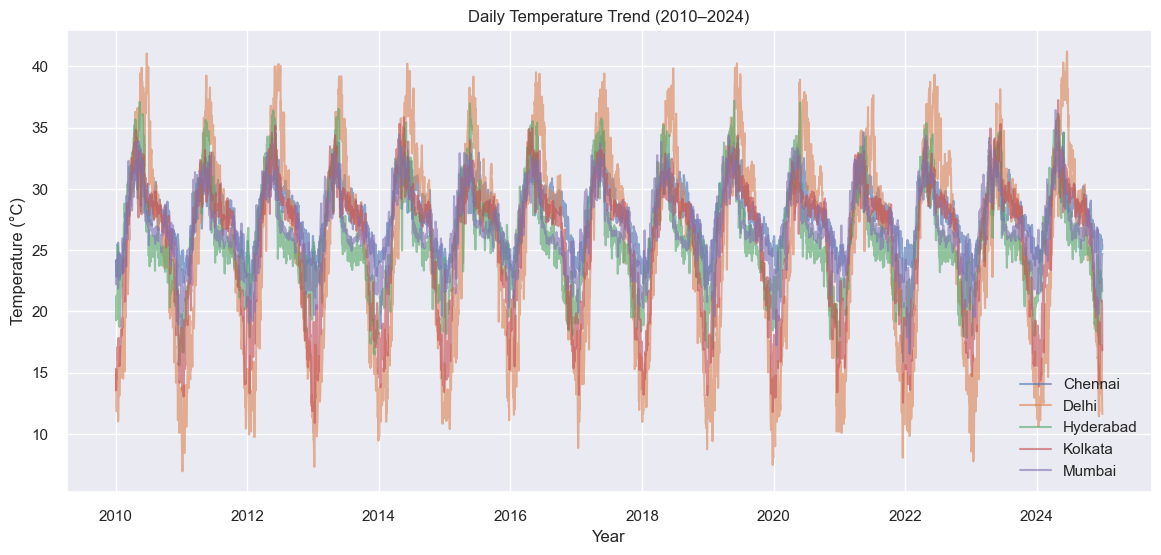

In [8]:
plt.figure(figsize=(14,6))

for city in df["City"].unique():
    city_df = df[df["City"] == city]
    plt.plot(city_df["Date"], city_df["T2M"], label=city, alpha=0.6)

plt.legend()
plt.title("Daily Temperature Trend (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

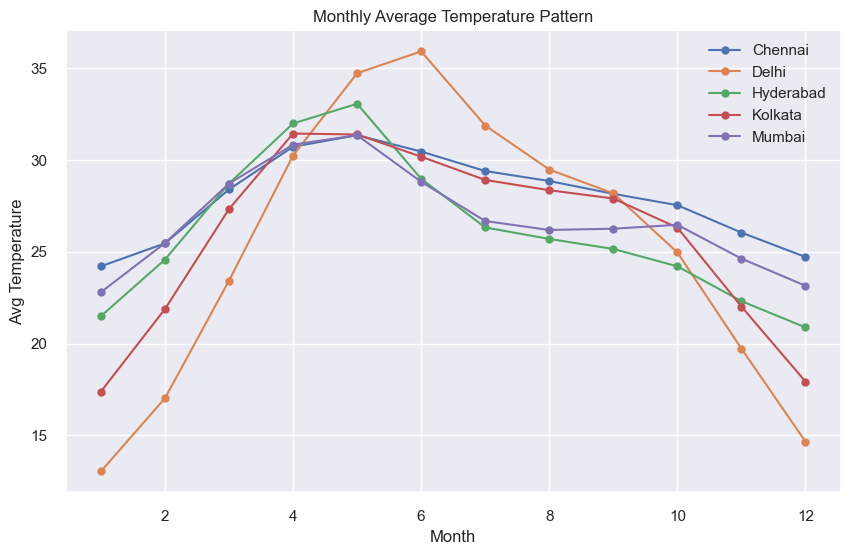

In [9]:
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby(["City", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,6))

for city in df["City"].unique():
    city_data = monthly_avg[monthly_avg["City"] == city]
    plt.plot(city_data["Month"], city_data["T2M"], marker='o', label=city)

plt.legend()
plt.title("Monthly Average Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Avg Temperature")
plt.show()

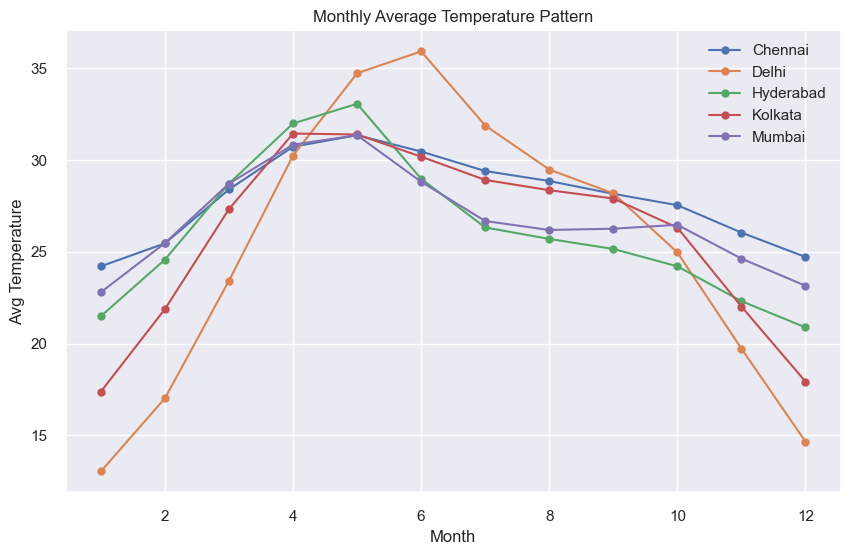

In [10]:
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby(["City", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,6))

for city in df["City"].unique():
    city_data = monthly_avg[monthly_avg["City"] == city]
    plt.plot(city_data["Month"], city_data["T2M"], marker='o', label=city)

plt.legend()
plt.title("Monthly Average Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Avg Temperature")
plt.show()

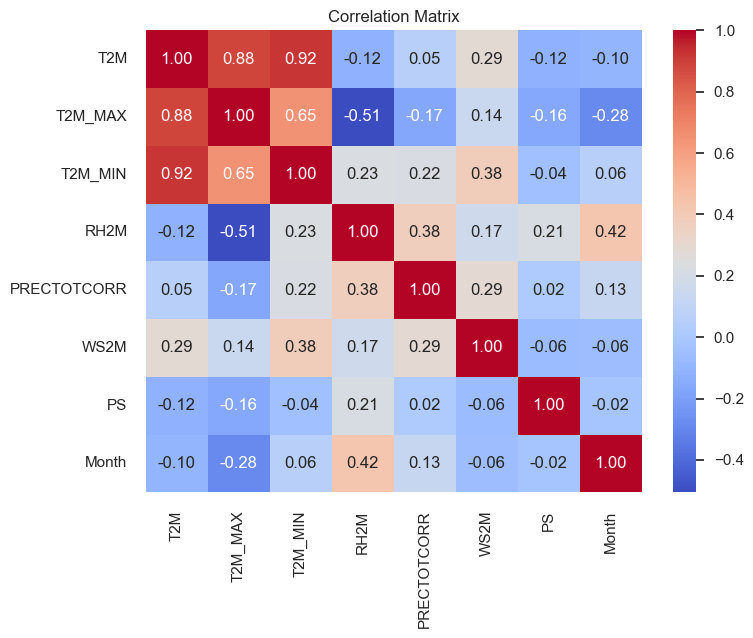

In [11]:
plt.figure(figsize=(8,6))
corr = df.drop(columns=["City", "Date"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

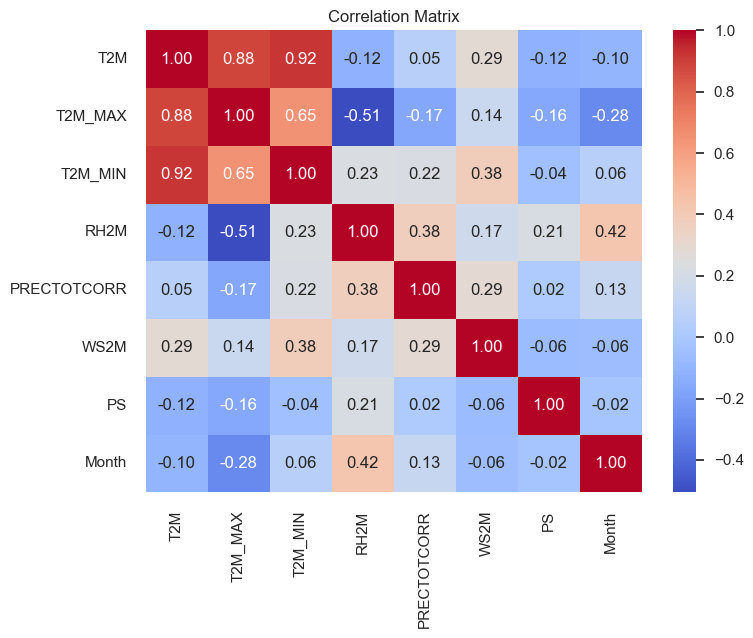

In [12]:
plt.figure(figsize=(8,6))
corr = df.drop(columns=["City", "Date"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

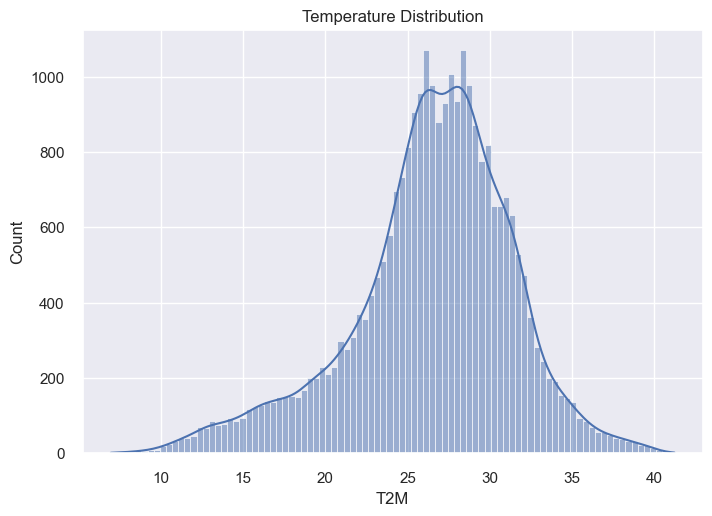

In [13]:
sns.histplot(df["T2M"], kde=True)
plt.title("Temperature Distribution")
plt.show()

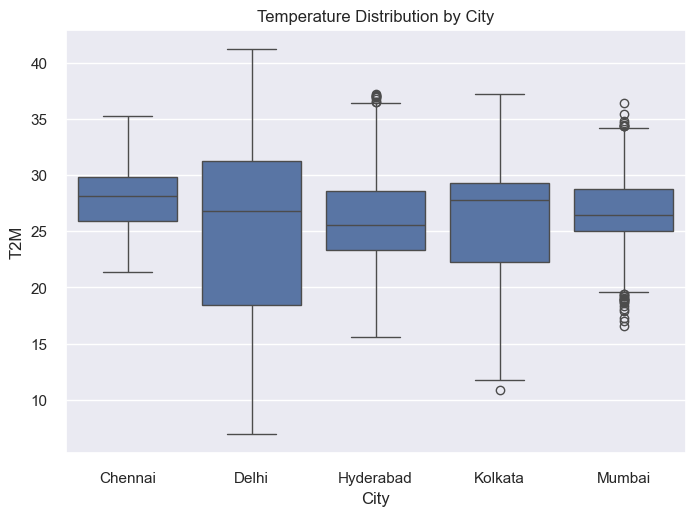

In [14]:
sns.boxplot(x="City", y="T2M", data=df)
plt.title("Temperature Distribution by City")
plt.show()

In [16]:
df = pd.read_csv("../data/processed/climate_with_target.csv")
df.head()

,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,PS,Date,City,Target_T2M
0,24.14,27.83,21.54,81.89,0.00,2.96,100.70,2010-01-01,Chennai,23.77
1,23.77,26.94,21.18,81.10,0.01,3.25,100.89,2010-01-02,Chennai,23.32
2,23.32,26.58,20.84,79.15,0.01,3.03,100.88,2010-01-03,Chennai,22.86
3,22.86,26.46,20.49,77.30,0.00,2.10,100.71,2010-01-04,Chennai,22.83
4,22.83,26.80,19.15,79.50,0.00,2.01,100.55,2010-01-05,Chennai,23.55


In [17]:
df.groupby("City").tail(3)

,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,PS,Date,City,Target_T2M
5475,25.21,28.05,23.33,82.48,0.23,3.17,100.92,2024-12-28,Chennai,25.14
5476,25.14,28.02,23.04,85.57,1.31,4.05,100.89,2024-12-29,Chennai,25.49
5477,25.49,28.28,23.61,85.18,1.47,4.10,100.87,2024-12-30,Chennai,25.13
10953,15.20,19.26,11.41,87.76,6.09,1.75,99.39,2024-12-28,Delhi,14.42
10954,14.42,22.34,9.35,72.73,0.08,2.52,99.48,2024-12-29,Delhi,12.35
10955,12.35,20.98,6.11,55.76,0.00,2.36,99.44,2024-12-30,Delhi,11.62
16431,22.19,29.11,17.48,75.97,0.00,2.18,96.01,2024-12-28,Hyderabad,22.42
16432,22.42,29.55,17.48,71.01,0.00,1.77,96.00,2024-12-29,Hyderabad,22.04
16433,22.04,29.43,15.59,62.70,0.00,1.58,95.99,2024-12-30,Hyderabad,21.66
21909,19.54,25.76,15.10,79.03,0.00,1.27,101.64,2024-12-28,Kolkata,20.90
